# Sundbyberg Heat Junior


數據解讀重點 (Insight)
根據你之前的輸出：

進攻核心 (RC & GPA)：FERRIS 的 RC 高達 11.176，是隊伍中創造得分能力最強的球員。

擊球運氣/品質 (BABIP)：ANDREASSON 的 BABIP 為 0.800，這是一個極端數據。這代表他擊出的場內球幾乎都形成安打，或者他擊球力量極大，讓防守方無法處理。在你的 XGBoost 模型中，這個指標可以作為預測球員未來表現是否會「校正回歸」的關鍵特徵。

選球紀律 (K% & BB%)：FERRIS 的三振率 (k_pct) 為 0，且創造得分最高，是極其穩定的打擊者。

In [1]:
import pandas as pd
import requests
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 抓取原始數據
url = "https://stats.baseboll-softboll.se/api/v1/stats/events/2025-regionserien-baseboll/index?section=players&stats-section=batting&team=&round=&split=&split=&language=en"
headers_api = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/146.0.0.0 Safari/537.36',
    'Accept': 'application/json'
}

try:
    response = requests.get(url, headers=headers_api)
    data = response.json()
    df_stats = pd.json_normalize(data['data'], sep='_')
    print("內部數據的實際欄位：")
    print(df_stats.columns.tolist())

    # 確保數值欄位型態正確
    numeric_cols = ['ab', 'h', 'hr', 'so', 'sf', 'bb', 'hbp', 'sh', 'tb', 'slg', 'avg', 'obp', 'ops']
    for col in numeric_cols:
        df_stats[col] = pd.to_numeric(df_stats[col], errors='coerce').fillna(0)

    # 2. 篩選：Stockholm B (ID: 36163) 且 打數 (AB) >= 10
    df_stats['teamid'] = df_stats['teamid'].astype(str)
    # --- 關鍵過濾行 ---
    df_sto_b = df_stats[(df_stats['teamid'] == '36169') & (df_stats['ab'] >= 10)].copy()

    # 3. 進階數據計算
    df_sto_b['pa'] = df_sto_b['ab'] + df_sto_b['bb'] + df_sto_b['hbp'] + df_sto_b['sf'] + df_sto_b['sh']
    df_sto_b['avg'] = df_sto_b['avg'] / 1000
    df_sto_b['ops'] = df_sto_b['ops'] / 1000
    df_sto_b['obp'] = df_sto_b['obp'] / 1000
    df_sto_b['slg'] = df_sto_b['slg'] / 1000
    
    def safe_divide(numerator, denominator):
        return np.where(denominator == 0, 0, numerator / denominator)

    # 計算 BABIP, ISO, K%, BB%, RC, GPA
    babip_denom = df_sto_b['ab'] - df_sto_b['so'] - df_sto_b['hr'] + df_sto_b['sf']
    df_sto_b['babip'] = safe_divide(df_sto_b['h'] - df_sto_b['hr'], babip_denom)
    df_sto_b['iso_val'] = (df_sto_b['slg'] - df_sto_b['avg']) 
    df_sto_b['k_pct'] = safe_divide(df_sto_b['so'], df_sto_b['pa'])
    df_sto_b['bb_pct'] = safe_divide(df_sto_b['bb'], df_sto_b['pa'])
    df_sto_b['rc'] = safe_divide((df_sto_b['h'] + df_sto_b['bb']) * df_sto_b['tb'], (df_sto_b['ab'] + df_sto_b['bb']))
    df_sto_b['gpa_val'] = (1.8 * (df_sto_b['obp']) + (df_sto_b['slg'])) / 4

    # 4. 清理球員姓名 (移除 HTML 標籤)
    def clean_name(text):
        return " ".join(re.sub(r'<[^>]*>', ' ', text).split())
    df_sto_b['name_clean'] = df_sto_b['name'].apply(clean_name)

except Exception as e:
    print(f"分析執行出錯: {e}")

內部數據的實際欄位：
['g', 'gs', 'ab', 'r', 'h', 'double', 'triple', 'hr', 'rbi', 'tb', 'avg', 'slg', 'obp', 'ops', 'bb', 'hbp', 'so', 'gdp', 'sf', 'sh', 'sb', 'cs', 'link', 'name', 'teamcode', 'teamid']


In [2]:
# 挑選想要輸出的欄位
output_columns = [
    'name_clean', 'ab', 'h','avg', 'ops', 'babip', 'iso_val', 
    'k_pct', 'bb_pct', 'rc', 'gpa_val'
]

# 根據 GPA 排行 (也可以改為 rc)，並取前 10 名
top_players = df_sto_b.sort_values(by='gpa_val', ascending=False)[output_columns]

print("=== Stockholm B 進階數據排行榜 (Top GPA) [AB>=10] ===")
# 使用 round(3) 讓小數點保持三位
print(top_players.round(2).to_string(index=False))

=== Stockholm B 進階數據排行榜 (Top GPA) [AB>=10] ===
         name_clean  ab  h  avg  ops  babip  iso_val  k_pct  bb_pct    rc  gpa_val
 NORDHAMREN Gabriel  42 17 0.40 1.00   0.41     0.12   0.06    0.14 10.78     0.34
    BRIENESSE Dante  30  8 0.27 0.94   0.29     0.17   0.06    0.30  6.50     0.34
      DIFUSCO David  20  6 0.30 0.80   0.33     0.00   0.07    0.21  2.77     0.30
BRIENESSE Sebastian  26  6 0.23 0.80   0.30     0.08   0.17    0.29  3.79     0.30
         ZABST Alex  38 10 0.26 0.80   0.40     0.08   0.25    0.19  5.42     0.29
     ULLBERG Valter  23  5 0.22 0.66   0.28     0.00   0.18    0.29  2.27     0.25
         KERO Einar  30  6 0.20 0.65   0.27     0.07   0.21    0.15  2.67     0.24
     BENGTSSON Axel  32  6 0.19 0.63   0.33     0.06   0.33    0.24  3.05     0.23
     LINDGREN Henry  40 10 0.25 0.64   0.30     0.05   0.17    0.11  4.00     0.23
       TIVENIN Nils  11  1 0.09 0.47   0.25     0.00   0.44    0.19  0.29     0.19
       SOMPHOT Nils  34  7 0.21 0.52   0

C:\Users\dechihao\AppData\Local\Temp\ipykernel_18352\2966312561.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_rc, x='rc', y='name_clean', palette='viridis')


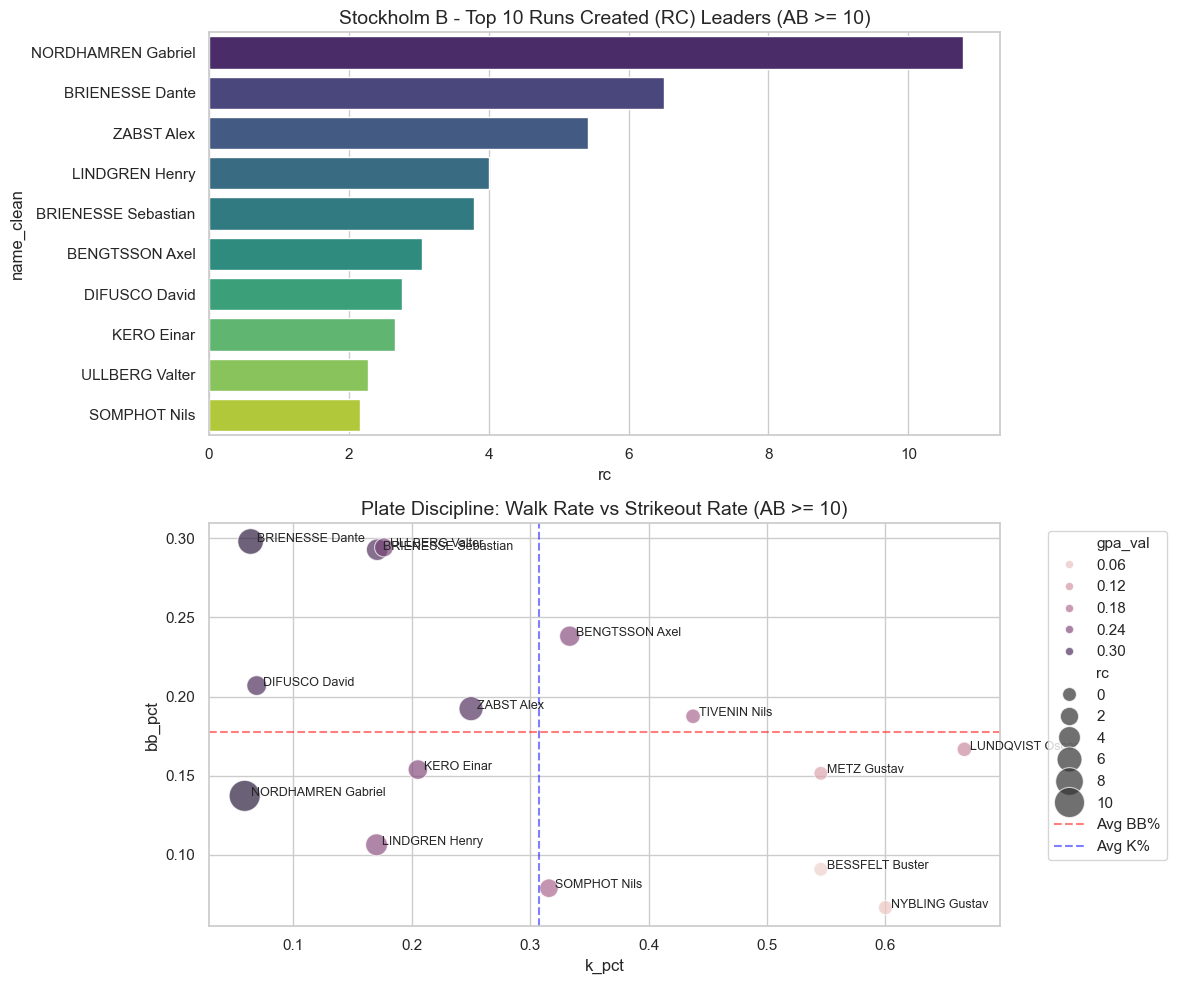

In [3]:
# 6. 視覺化分析
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 10))
# A. 創造得分 (RC) 排行
plt.subplot(2, 1, 1)
top_rc = df_sto_b.sort_values('rc', ascending=False).head(10)
sns.barplot(data=top_rc, x='rc', y='name_clean', palette='viridis')
plt.title('Stockholm B - Top 10 Runs Created (RC) Leaders (AB >= 10)', fontsize=14)
# B. 選球紀律分析 (K% vs BB%)
plt.subplot(2, 1, 2)
sns.scatterplot(data=df_sto_b, x='k_pct', y='bb_pct', size='rc', hue='gpa_val', sizes=(100, 500), alpha=0.7)
plt.axhline(df_sto_b['bb_pct'].mean(), color='red', linestyle='--', alpha=0.5, label='Avg BB%')
plt.axvline(df_sto_b['k_pct'].mean(), color='blue', linestyle='--', alpha=0.5, label='Avg K%')

    # 標註球員姓名
for i in range(len(df_sto_b)):
    plt.text(df_sto_b.iloc[i]['k_pct']+0.005, df_sto_b.iloc[i]['bb_pct'], df_sto_b.iloc[i]['name_clean'], fontsize=9)

plt.title('Plate Discipline: Walk Rate vs Strikeout Rate (AB >= 10)', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.tight_layout()
plt.show()